In [3]:
np.sqrt(0.07**2+0.04**2)

0.0806225774829855

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','notebook','grid'])
from Metrics import PhotoZMetrics
from astropy.table import Table,vstack,join,unique
import fitsio
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from astropy.coordinates import SkyCoord
import astropy.units as u
from catboost_cv import PhotoZCatBoostPipeline
from catboost import CatBoostRegressor, Pool

from scipy.stats import gaussian_kde



/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def match_coords(table1, table2, max_sep=1.5*u.arcsec):
    coords1 = SkyCoord(ra=table1['RA']*u.degree, dec=table1['DEC']*u.degree)
    coords2 = SkyCoord(ra=table2['RA']*u.degree, dec=table2['DEC']*u.degree)

    idx2, d2d, _ = coords1.match_to_catalog_sky(coords2)
    keep = d2d < max_sep

    idx1_keep = np.where(keep)[0]      # rows in table1
    idx2_keep = idx2[keep]             # rows in table2
    sep_keep = d2d[keep]

    matched_table1 = table1[idx1_keep]
    matched_table2 = table2[idx2_keep]

    return matched_table1, matched_table2, idx1_keep, idx2_keep, sep_keep

In [3]:
north_FP = Table(fitsio.FITS(f'/user/animesh.sah/FP_CUTS/table_north_unique.fits')[1].read())
south_FP = Table(fitsio.FITS(f'/user/animesh.sah/FP_CUTS/table_south_unique.fits')[1].read())
north_FP  = north_FP[north_FP['DEC']>=32.375]
south_FP  = south_FP[south_FP['DEC']<32.375]
np.count_nonzero(north_FP['DEC']<32.375), np.count_nonzero(south_FP['DEC']>=32.375)
cfg =  PhotoZCatBoostPipeline.load_config('/user/animesh.sah/DESI_PECVEL/ML_photoz/runs/RUN7_north/logs/config_used.yaml')
dr_north = fitsio.FITS(cfg['data']['dr1']['north'])[1].read()
dr_south = fitsio.FITS(cfg['data']['dr1']['south'])[1].read()
legacy_north = fitsio.FITS(cfg['data']['legacy']['north'])[1].read()
legacy_south = fitsio.FITS(cfg['data']['legacy']['south'])[1].read()

INFO:catboost_cv:Config loaded from /user/animesh.sah/DESI_PECVEL/ML_photoz/runs/RUN7_north/logs/config_used.yaml


In [4]:

matched_north_FP, matched_dr_north, idx_north_fp, idx_north_dr, sep_north = match_coords(north_FP, Table(dr_north))
matched_south_FP, matched_dr_south, idx_south_fp, idx_south_dr, sep_south = match_coords(south_FP, Table(dr_south))

In [5]:
np.count_nonzero(north_FP['Z_SPEC'] > 0), np.count_nonzero(south_FP['Z_SPEC'] > 0)

(59726, 131253)

In [6]:
np.count_nonzero(north_FP['TRAINING'] == True), np.count_nonzero(south_FP['TRAINING'] == True)

(37968, 60479)

In [7]:
north_FP

BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,DCHISQ,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_W3,FLUX_W4,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FLUX_IVAR_W3,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,MW_TRANSMISSION_W3,MW_TRANSMISSION_W4,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,PSFSIZE_G,PSFSIZE_R,PSFSIZE_Z,PSFDEPTH_G,PSFDEPTH_R,PSFDEPTH_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,R_CIRC,MAG_G,MAG_R,MAG_Z,MAG_W1,FIBERMAG_G,FIBERMAG_R,FIBERMAG_Z,MAG_NOEXT_G,MAG_NOEXT_R,MAG_NOEXT_Z,Z_PHOT_MEDIAN,Z_PHOT_L95,Z_SPEC,SURVEY,TRAINING
int32,str8,int32,str3,float64,float64,float32[5],float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,str10,bool
534553,1757p380,9,SER,175.57140970668283,38.12215833466594,2076314.9 .. 3149468.8,0.021125494,153.39125,349.25937,609.29645,428.99466,246.85588,27.224644,-221.02383,16.586782,5.932871,5.489075,0.6750608,0.31286222,0.0008666603,0.93937945,0.9587499,0.97671264,0.9964263,0.99780375,0.9995312,0.999823,2,3,3,8.040825e-05,6.690163e-05,3.1822052e-05,0.008204867,0.008300377,0.0077318065,0.9966541,0.9966603,0.9963436,1.5305895,1.5710931,1.2004011,619.4126,182.35287,123.02439,1.942084,-0.18661349,0.048183963,37.219196,84.74507,147.84105,18.174925,0,4.100392,1.5977347,16.967602,16.096394,15.512345,15.914984,18.505184,17.633978,17.049929,17.035498,16.14213,15.537929,0.050405994,0.04159412,0.04821726,SDSS,True
529972,1764p370,10,SER,176.2500631334883,37.05252847740415,291328.38 .. 375979.56,0.019466436,42.98839,105.60008,200.5259,168.95343,104.228035,256.99,-6369.9087,40.85771,12.1211605,5.7702165,0.9071439,0.30910853,0.0005006191,0.94400424,0.9619269,0.9785217,0.9967064,0.99797606,0.999568,0.99983686,3,4,3,0.042814896,0.014413725,0.0016032592,0.09045516,0.0898245,0.07068946,0.9282182,0.9286859,0.89927304,1.8631879,1.544222,1.3040656,719.9234,288.98575,114.19577,3.4540436,-0.0407132,-0.00555108,7.579413,18.61867,35.355324,19.951244,0,6.0,3.314917,18.354057,17.398693,16.721,16.927,20.238346,19.282984,18.60529,18.416622,17.440838,16.744574,0.10348889,0.0657438,0.114727534,SDSS,False
530129,2254p370,12,SER,225.31300315193764,37.092314442026925,493774.7 .. 701193.44,0.022007912,37.736828,96.7153,197.94489,257.31638,198.39363,938.217,2286.2278,86.30007,15.629554,11.014637,1.1078241,0.45690867,0.0020680253,0.93692887,0.9570644,0.9757518,0.9962773,0.99771214,0.9995116,0.9998156,3,3,3,0.016975468,0.01064221,0.0010992922,0.0015772042,0.0014538141,0.0014423738,0.99839914,0.9986394,0.99900496,1.8352568,1.4568543,1.2021089,876.00415,186.86491,98.783134,1.6732689,0.34688634,0.07797406,10.119269,25.934565,53.07965,19.70243,0,2.5164406,1.1537365,18.487352,17.488613,16.731987,16.469782,19.916393,18.917656,18.161028,18.558086,17.536263,16.75864,0.1493897,0.08301443,0.12690881,SDSS,False
536791,1661p385,12,SER,165.98245635758786,38.423174026160815,1808168.1 .. 2319038.2,0.016012974,117.11932,283.94162,525.63654,383.23123,223.75371,174.29738,-1720.8958,32.618813,8.6404705,4.2531185,0.73812705,0.34222284,0.0010656422,0.95370424,0.9685739,0.98229814,0.99728996,0.9983348,0.99964464,0.9998658,3,3,2,0.0074452176,0.0047917766,0.0013191422,0.0054063383,0.0053933603,0.006278581,0.9987793,0.9988664,0.6748485,1.5308626,1.5796006,1.6119448,694.69055,201.06877,50.335968,2.1289365,0.1663964,-0.28042847,32.99087,79.98237,148.06444,18.3355,0,6.0,1.517687,17.276962,16.33226,15.678894,16.0384,18.65255,17.707846,17.0

In [7]:
def spec_not_train(tab):
    return tab[(tab['Z_SPEC'] > 0) & (tab['TRAINING'] == False)]

def spec_train(tab):
    return tab[(tab['Z_SPEC'] > 0) & (tab['TRAINING'] == True)]


In Training and have SPEC

In [8]:
np.unique(north_FP[north_FP['TRAINING'] == True]['SURVEY'],return_counts=True), np.unique(south_FP[south_FP['TRAINING'] == True]['SURVEY'],return_counts=True)

((<Column name='SURVEY' dtype='str10' length=3>
  AGES
  BOSS
  SDSS,
  array([   25,  2182, 35761])),
 (<Column name='SURVEY' dtype='str10' length=8>
     2dFLenS
        BOSS
  COSMOS2015
        GAMA
       OzDES
        SDSS
     WiggleZ
   eBOSS-LRG,
  array([  833, 11648,     2,  1734,   207, 46017,    37,     1])))

Have SPEC but not in training

In [9]:
np.unique(np.array(north_FP[north_FP['TRAINING'] == False]['SURVEY']),return_counts=True), np.unique(np.array(south_FP[south_FP['TRAINING'] == False]['SURVEY']),return_counts=True)

((array([' ', 'SDSS'], dtype='<U10'), array([82014, 21758])),
 (array([' ', 'BOSS', 'SDSS'], dtype='<U10'), array([199568,    359,  70415])))

Text(0, 0.5, 'Density')

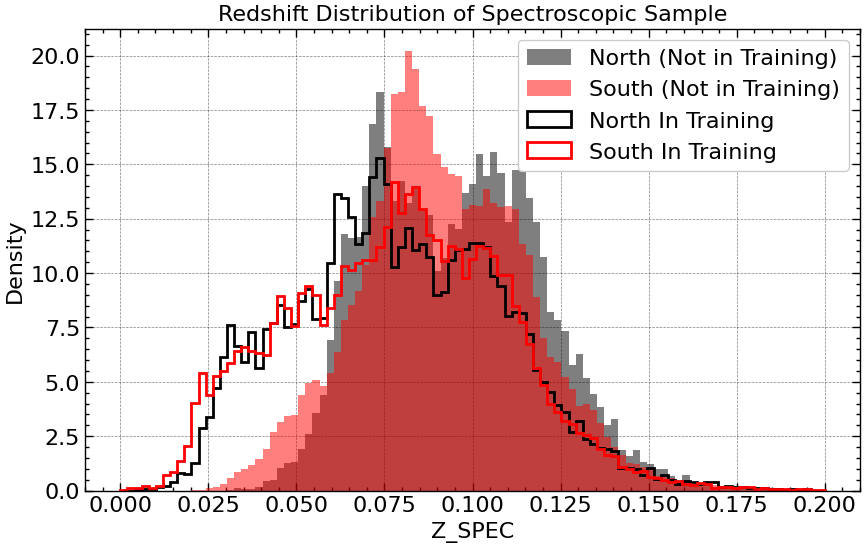

In [10]:

plt.figure(figsize=(10,6))
bins = np.linspace(0, 0.2, 100)
plt.hist(spec_not_train(north_FP)['Z_SPEC'], bins=bins, alpha=0.5, label='North (Not in Training)', density=True,color = 'k')
plt.hist(spec_not_train(south_FP)['Z_SPEC'], bins=bins, alpha=0.5, label='South (Not in Training)', density=True,color = 'r')
plt.legend()
plt.xlabel('Z_SPEC')
plt.ylabel('Density')   

plt.hist(spec_train(north_FP)['Z_SPEC'], bins=bins, label='North In Training', density=True, histtype='step', color='k',lw =2)
plt.hist(spec_train(south_FP)['Z_SPEC'], bins=bins,label='South In Training', density=True, histtype='step', color='r',lw=2 )
plt.title('Redshift Distribution of Spectroscopic Sample')
plt.legend()
plt.xlabel('Z_SPEC')
plt.ylabel('Density')   

In [11]:
print('Fraction of FP sample with DR1 spectroscopic redshifts:')
print('North:', len(matched_north_FP)/len(north_FP))
print('South:', len(matched_south_FP)/len(south_FP))

Fraction of FP sample with DR1 spectroscopic redshifts:
North: 0.2589036263581205
South: 0.2815087313078674


In [12]:
print('DR1 objects with prior spectroscopic redshifts:')
print('North:', np.count_nonzero(matched_north_FP['Z_SPEC']>0), 'out of', len(matched_north_FP), '(Fraction: {:.2f}%)'.format(100*np.count_nonzero(matched_north_FP['Z_SPEC']>0)/len(matched_north_FP)))
print('South:', np.count_nonzero(matched_south_FP['Z_SPEC']>0), 'out of', len(matched_south_FP), '(Fraction: {:.2f}%)'.format(100*np.count_nonzero(matched_south_FP['Z_SPEC']>0)/len(matched_south_FP)))

print('FP sample with spectroscopic redshifts:')
print('North Z_SPEC:', np.count_nonzero(north_FP['Z_SPEC']>0), 'out of', len(north_FP), '(Fraction: {:.2f}%)'.format(100*np.count_nonzero(north_FP['Z_SPEC']>0)/len(north_FP)))
print('South Z_SPEC:', np.count_nonzero(south_FP['Z_SPEC']>0), 'out of', len(south_FP), '(Fraction: {:.2f}%)'.format(100*np.count_nonzero(south_FP['Z_SPEC']>0)/len(south_FP)))


mask_north = north_FP['Z_SPEC']>0
mask_south = south_FP['Z_SPEC']>0

DR1 objects with prior spectroscopic redshifts:
North: 17905 out of 36697 (Fraction: 48.79%)
South: 42158 out of 93129 (Fraction: 45.27%)
FP sample with spectroscopic redshifts:
North Z_SPEC: 59726 out of 141740 (Fraction: 42.14%)
South Z_SPEC: 131253 out of 330821 (Fraction: 39.67%)


### Total number of objects which have spectroscopic redshift

In [80]:
idx_north_fp

array([     0,      1,      3, ..., 141549, 141578, 141613])

In [13]:
def build_redshift_indices(fp_table, idx_dr1_fp):
    n = len(fp_table)

    mask_dr1 = np.zeros(n, dtype=bool)
    mask_dr1[idx_dr1_fp] = True

    mask_spec = fp_table['Z_SPEC'] > 0

    mask_common = mask_dr1 & mask_spec
    
    mask_fp_only = mask_spec & ~mask_dr1
    
    idx_dr1 = np.where(mask_dr1)[0]
    idx_common = np.where(mask_common)[0]
    idx_fp_only = np.where(mask_fp_only)[0]
    matched_common_idx = np.where(
        fp_table['Z_SPEC'][idx_dr1_fp] > 0
    )[0]

    return idx_dr1, idx_fp_only, idx_common, matched_common_idx
##idx_dr1_north = rows in north_FP that have a DR1 match
##idx_fp_only_north = rows in north_FP with Z_SPEC > 0 but not in DR1
##idx_common_north = rows in north_FP that have both DR1 and Z_SPEC > 0
idx_dr1_north, idx_fp_only_north, idx_common_north,idx_common_d1_north = build_redshift_indices(north_FP, idx_north_fp)
idx_dr1_south, idx_fp_only_south, idx_common_south,idx_common_d1_south = build_redshift_indices(south_FP, idx_south_fp)

In [14]:
z_source_north = np.full(len(north_FP), 'NONE', dtype='U8')
z_source_north[idx_dr1_north] = 'DR1'
z_source_north[idx_fp_only_north] = 'Z_SPEC'

z_use_north = np.full(len(north_FP), np.nan)

# replace 'DR1_Z' with your actual DR1 redshift column name
z_use_north[idx_dr1_north] = matched_dr_north['Z']
z_use_north[idx_fp_only_north] = north_FP['Z_SPEC'][idx_fp_only_north]

In [15]:
z_source_south = np.full(len(south_FP), 'NONE', dtype='U8')
z_source_south[idx_dr1_south] = 'DR1'
z_source_south[idx_fp_only_south] = 'Z_SPEC'

z_use_south = np.full(len(south_FP), np.nan)
z_use_south[idx_dr1_south] = matched_dr_south['Z']
z_use_south[idx_fp_only_south] = south_FP['Z_SPEC'][idx_fp_only_south]

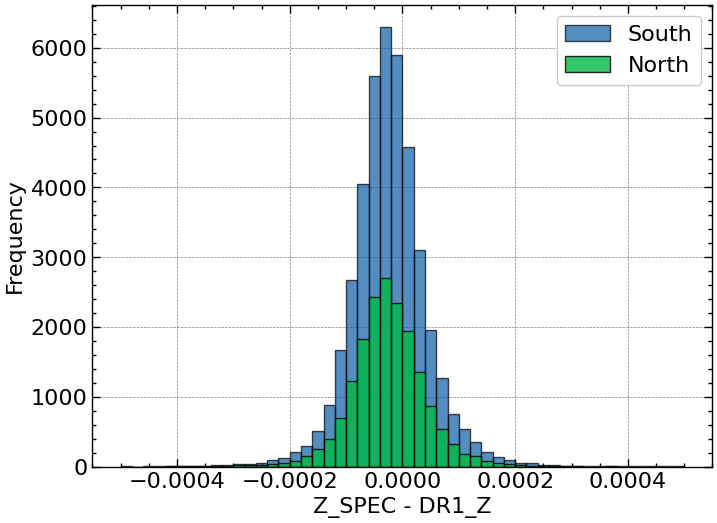

In [16]:
plt.hist(south_FP[idx_common_south]['Z_SPEC'] - matched_dr_south['Z'][idx_common_d1_south], bins = 50,range=(-0.0005,0.0005),label='South',alpha=0.7,edgecolor='black') #, idx_common_south
plt.hist(north_FP[idx_common_north]['Z_SPEC'] - matched_dr_north['Z'][idx_common_d1_north], bins = 50,range=(-0.0005,0.0005),label='North',alpha =0.8,edgecolor='black' ) #, idx_common_south

plt.xlabel('Z_SPEC - DR1_Z')
plt.ylabel('Frequency')
plt.legend()

In [17]:
print('Percentage of FP sample with redshifts (DR1 or Z_SPEC):')
print('North',round(100*(len(matched_dr_north['Z'])+len(north_FP[idx_fp_only_north]['Z_SPEC']))/len(north_FP), 2), 'South',round(100*(len(matched_dr_south['Z'])+len(south_FP[idx_fp_only_south]['Z_SPEC']))/len(south_FP), 2))
print('Out of which DR1 redshifts are:')
print('North',round(100*len(matched_dr_north['Z'])/len(north_FP), 2), '% South',round(100*len(matched_dr_south['Z'])/len(south_FP), 2),'%')


Percentage of FP sample with redshifts (DR1 or Z_SPEC):
North 55.4 South 55.08
Out of which DR1 redshifts are:
North 25.89 % South 28.15 %


In [21]:
def make_ids(tab):
    return set(zip(tab['BRICKID'],
                   tab['BRICKNAME'],
                   tab['OBJID']))


In [20]:
for region, fp, matched_fp in [
    ('North', north_FP, matched_north_FP),
    ('South', south_FP, matched_south_FP)
]:

    # FP objects with spectroscopy
    fp_spec = fp[fp['Z_SPEC'] > 0]

    # IDs
    fp_spec_ids = make_ids(fp_spec)
    matched_ids = make_ids(matched_fp)

    # Common objects
    common_ids = fp_spec_ids & matched_ids

    print(f'\n{region}')
    print('-'*40)
    print(f'FP objects                 : {len(fp)}')
    print(f'FP objects with Z_SPEC>0   : {len(fp_spec_ids)}')
    print(f'Matched DR1 objects        : {len(matched_ids)}')
    print(f'Common (DR1 + Z_SPEC>0)    : {len(common_ids)}')

    # useful fractions
    print(f'Fraction of spectroscopic sample in DR1 : '
          f'{100*len(common_ids)/len(fp_spec_ids):.2f}%')

    print(f'Fraction of DR1 sample with spectroscopy : '
          f'{100*len(common_ids)/len(matched_ids):.2f}%')



North
----------------------------------------
FP objects                 : 141740
FP objects with Z_SPEC>0   : 59726
Matched DR1 objects        : 36697
Common (DR1 + Z_SPEC>0)    : 17905
Fraction of spectroscopic sample in DR1 : 29.98%
Fraction of DR1 sample with spectroscopy : 48.79%

South
----------------------------------------
FP objects                 : 330821
FP objects with Z_SPEC>0   : 131253
Matched DR1 objects        : 93129
Common (DR1 + Z_SPEC>0)    : 42158
Fraction of spectroscopic sample in DR1 : 32.12%
Fraction of DR1 sample with spectroscopy : 45.27%


In [68]:
(59726+36697-17905)/ 141740

0.5539579511782137

In [22]:
rows = []

for region, fp, matched_fp in [
    ('North', north_FP, matched_north_FP),
    ('South', south_FP, matched_south_FP)
]:

    dr1_ids = make_ids(matched_fp)
    fp_spec_ids = make_ids(fp[fp['Z_SPEC'] > 0])

    common = dr1_ids & fp_spec_ids
    fp_only = fp_spec_ids - dr1_ids

    rows.append([
        region,
        len(dr1_ids),
        len(fp_only),
        len(common),
        len(dr1_ids) + len(fp_only)
    ])

for row in rows:
    print(f'{row[0]:<8} DR1={row[1]:>8}  FP-only={row[2]:>8}  Common={row[3]:>8}  Total={row[4]:>8}')

North    DR1=   36697  FP-only=   41821  Common=   17905  Total=   78518
South    DR1=   93129  FP-only=   89095  Common=   42158  Total=  182224


In [23]:
# Unique IDs
fp_ids = list(zip(north_FP['BRICKID'],
                  north_FP['BRICKNAME'],
                  north_FP['OBJID']))

fp_matched_ids = set(zip(matched_north_FP['BRICKID'],
                  matched_north_FP['BRICKNAME'],
                  matched_north_FP['OBJID']))

mask_fp_matched  = np.array([id_ in fp_matched_ids for id_ in fp_ids])
mask_spec = north_FP['Z_SPEC'] > 0
mask_common = mask_fp_matched & mask_spec
mask_fp_only = (~mask_fp_matched) & mask_spec

idx_fp_matched = np.where(mask_fp_matched)[0]
idx_fp_only = np.where(mask_fp_only)[0]
idx_common = np.where(mask_common)[0]

In [ ]:
/user/animesh.sah/DESI_PECVEL/ML_photoz/redshift_training_data.ipynb

/tmp/ipykernel_671649/3194228618.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_671649/3194228618.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_671649/3194228618.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'Density')

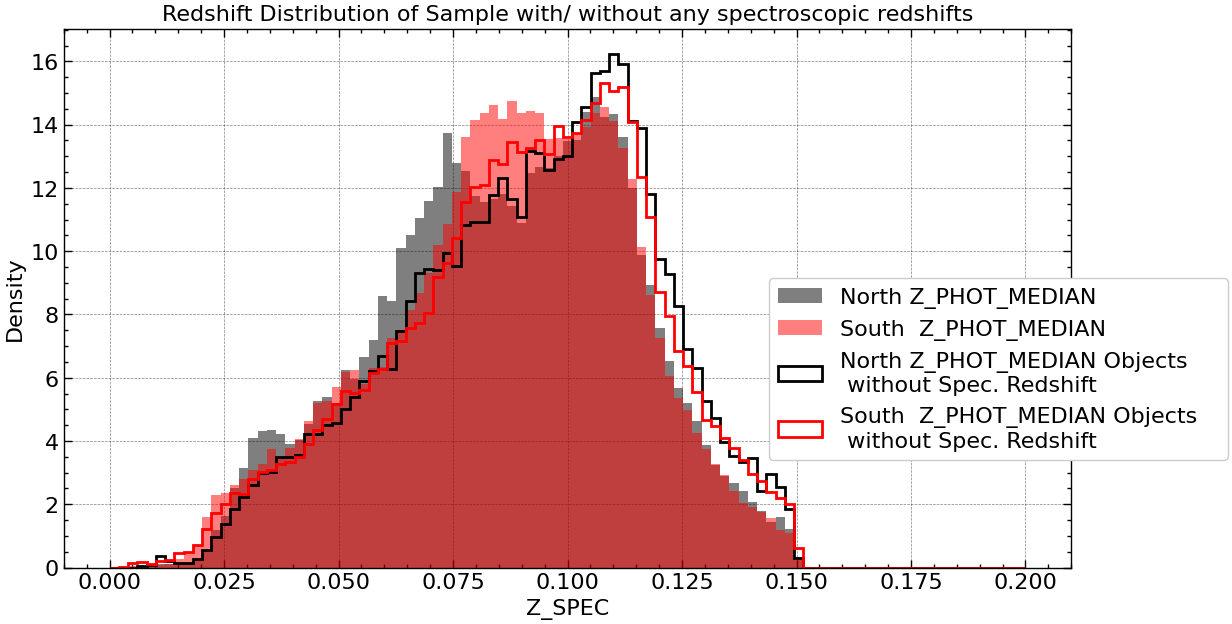

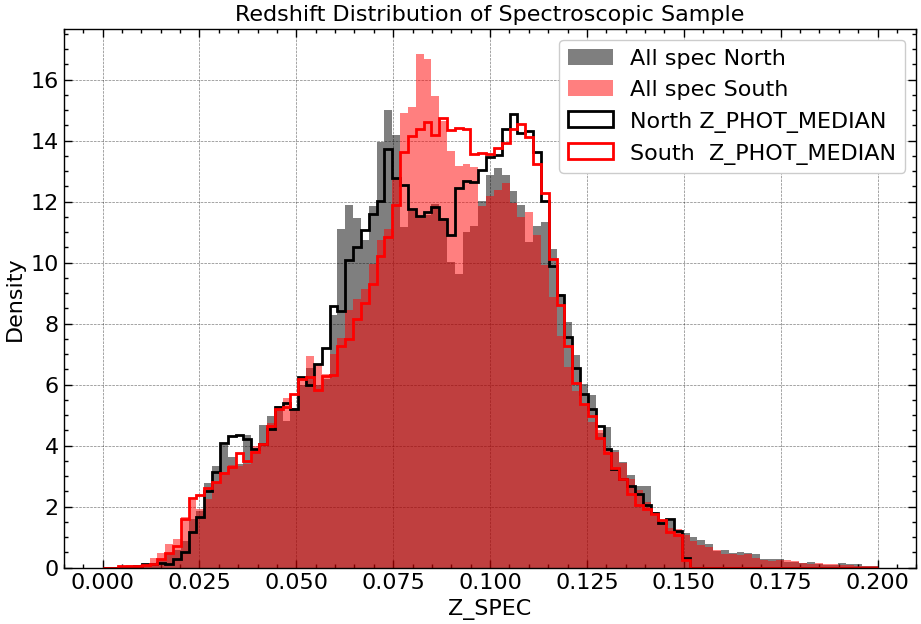

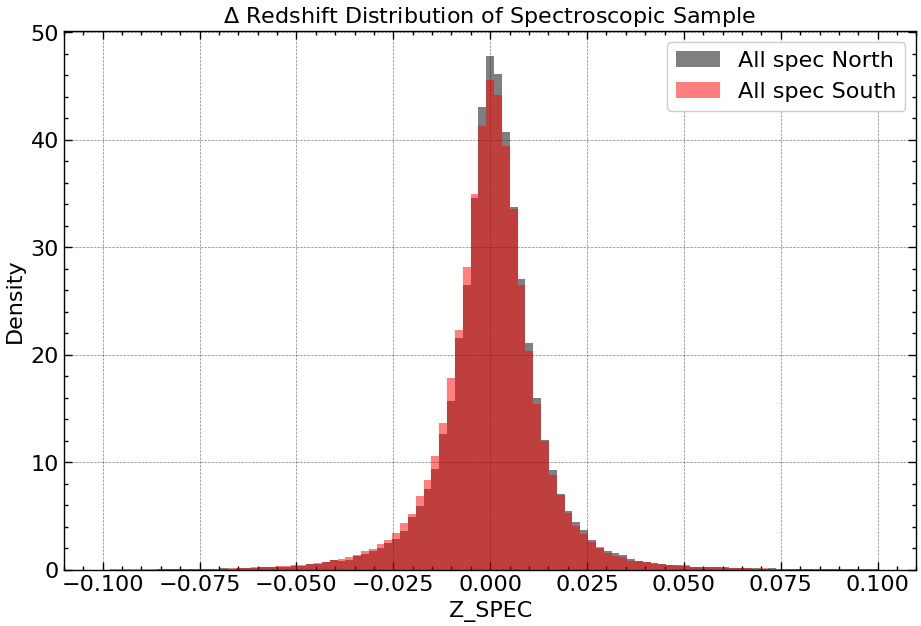

In [51]:



plt.figure(figsize=(13,7))
bins = np.linspace(0, 0.2, 100)
# plt.hist(spec_not_train(north_FP)['Z_SPEC'], bins=bins, alpha=0.5, label='North (Not in Training)', density=True,color = 'k')
# plt.hist(spec_not_train(south_FP)['Z_SPEC'], bins=bins, alpha=0.5, label='South (Not in Training)', density=True,color = 'r')
plt.legend()
plt.xlabel('Z_SPEC')
plt.ylabel('Density')   
#plt.hist(z_use_north[np.isfinite(z_use_north)], bins=bins, alpha=0.5, label='All spec North',density=True,color='k',lw=2)
#plt.hist(z_use_south[np.isfinite(z_use_south)], bins=bins, alpha=0.5, label='All spec South',density=True,color='r',lw=2)
plt.hist(north_FP['Z_PHOT_MEDIAN'][np.isfinite(z_use_north)], bins=bins, label='North Z_PHOT_MEDIAN',density=True,color='k',lw=2,alpha=0.5)
plt.hist(south_FP['Z_PHOT_MEDIAN'][np.isfinite(z_use_south)], bins=bins,label='South  Z_PHOT_MEDIAN',density=True,color='r',lw=2,alpha=0.5)
plt.hist(north_FP['Z_PHOT_MEDIAN'][~np.isfinite(z_use_north)], bins=bins, label='North Z_PHOT_MEDIAN Objects \n without Spec. Redshift', density=True, histtype='step', color='k',lw =2)
plt.hist(south_FP['Z_PHOT_MEDIAN'][~np.isfinite(z_use_south)], bins=bins,label='South  Z_PHOT_MEDIAN Objects   \n without Spec. Redshift', density=True, histtype='step', color='r',lw=2 )
plt.title('Redshift Distribution of Sample with/ without any spectroscopic redshifts')
plt.legend(loc =(0.7,0.2))
plt.xlabel('Z_SPEC')
plt.ylabel('Density')   


plt.figure(figsize=(11,7))
bins = np.linspace(0, 0.2, 100)
# plt.hist(spec_not_train(north_FP)['Z_SPEC'], bins=bins, alpha=0.5, label='North (Not in Training)', density=True,color = 'k')
# plt.hist(spec_not_train(south_FP)['Z_SPEC'], bins=bins, alpha=0.5, label='South (Not in Training)', density=True,color = 'r')
plt.legend()
plt.xlabel('Z_SPEC')
plt.ylabel('Density')   
plt.hist(z_use_north[np.isfinite(z_use_north)], bins=bins, alpha=0.5, label='All spec North',density=True,color='k',lw=2)
plt.hist(z_use_south[np.isfinite(z_use_south)], bins=bins, alpha=0.5, label='All spec South',density=True,color='r',lw=2)

plt.hist(north_FP['Z_PHOT_MEDIAN'][np.isfinite(z_use_north)], bins=bins, label='North Z_PHOT_MEDIAN', density=True, histtype='step', color='k',lw =2)
plt.hist(south_FP['Z_PHOT_MEDIAN'][np.isfinite(z_use_south)], bins=bins,label='South  Z_PHOT_MEDIAN', density=True, histtype='step', color='r',lw=2 )
plt.title('Redshift Distribution of Spectroscopic Sample')
plt.legend()
plt.xlabel('Z_SPEC')
plt.ylabel('Density')   


plt.figure(figsize=(11,7))
bins = np.linspace(-0.1, 0.1, 100)
# plt.hist(spec_not_train(north_FP)['Z_SPEC'], bins=bins, alpha=0.5, label='North (Not in Training)', density=True,color = 'k')
# plt.hist(spec_not_train(south_FP)['Z_SPEC'], bins=bins, alpha=0.5, label='South (Not in Training)', density=True,color = 'r')
plt.legend()
plt.xlabel('Z_SPEC')
plt.ylabel('Density')   
plt.hist(z_use_north[np.isfinite(z_use_north)] -north_FP['Z_PHOT_MEDIAN'][np.isfinite(z_use_north)] , bins=bins, alpha=0.5, label='All spec North',density=True,color='k',lw=2)
plt.hist(z_use_south[np.isfinite(z_use_south)] -south_FP['Z_PHOT_MEDIAN'][np.isfinite(z_use_south)] , bins=bins, alpha=0.5, label='All spec South',density=True,color='r',lw=2)

plt.title('$\Delta$ Redshift Distribution of Spectroscopic Sample')
plt.legend()
plt.xlabel('Z_SPEC')
plt.ylabel('Density')   

## Redshift rates 

In [50]:
area_n = 5063.46 

area_s = 11484.06
area_tot = area_n + area_s
omega = area_tot * (np.pi/180)**2

In [53]:
omega / 4 / np.pi

0.4011232042216834

/tmp/ipykernel_3332538/2481140441.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


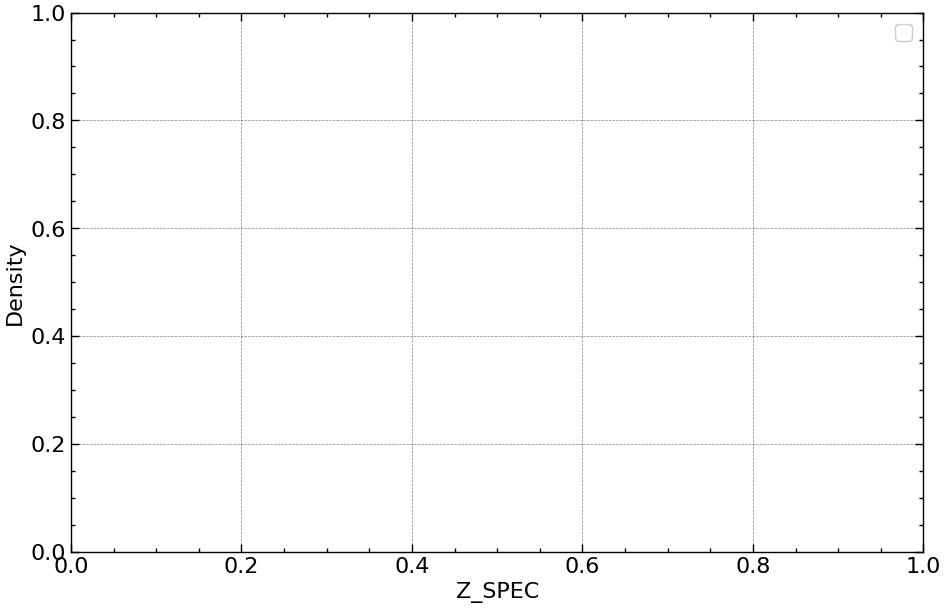

In [54]:
plt.figure(figsize=(11,7))
bins = np.linspace(0, 0.2, 100)
# plt.hist(spec_not_train(north_FP)['Z_SPEC'], bins=bins, alpha=0.5, label='North (Not in Training)', density=True,color = 'k')
# plt.hist(spec_not_train(south_FP)['Z_SPEC'], bins=bins, alpha=0.5, label='South (Not in Training)', density=True,color = 'r')
plt.legend()
plt.xlabel('Z_SPEC')
plt.ylabel('Density')   

z_tot = np.concatenate([z_use_north[np.isfinite(z_use_north)], z_use_south[np.isfinite(z_use_south)]])

zbins = np.linspace(0, 0.2, 50)
N, edges = np.histogram(z_tot, bins=zbins)
dz = np.diff(edges)
zcen = 0.5*(edges[1:] + edges[:-1])
dN_dz = N / dz
dN_dz_dOmega = N / (area_tot * dz)

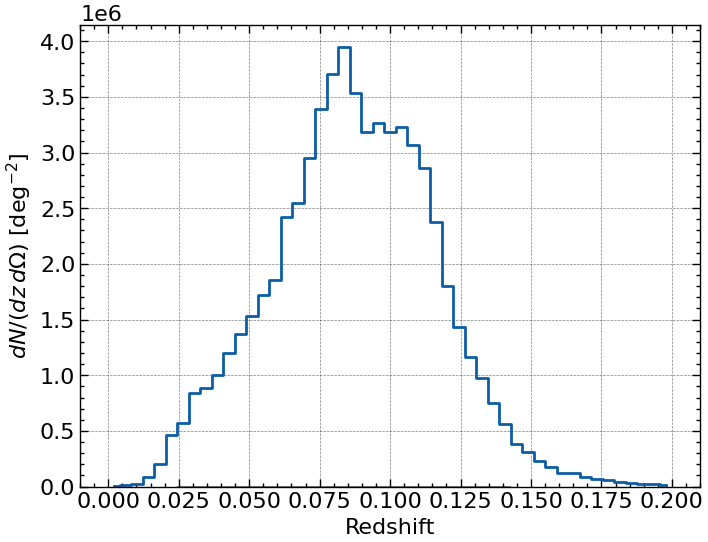

In [55]:

plt.plot(zcen, dN_dz, drawstyle='steps-mid')
plt.hist(z_use_north[np.isfinite(z_use_north)], bins=zbins, alpha=0.5, label='All spec North', color='k', lw=2)
plt.xlabel('Redshift')
plt.ylabel(r'$dN/(dz\, d\Omega)$ [deg$^{-2}$]')
plt.show()

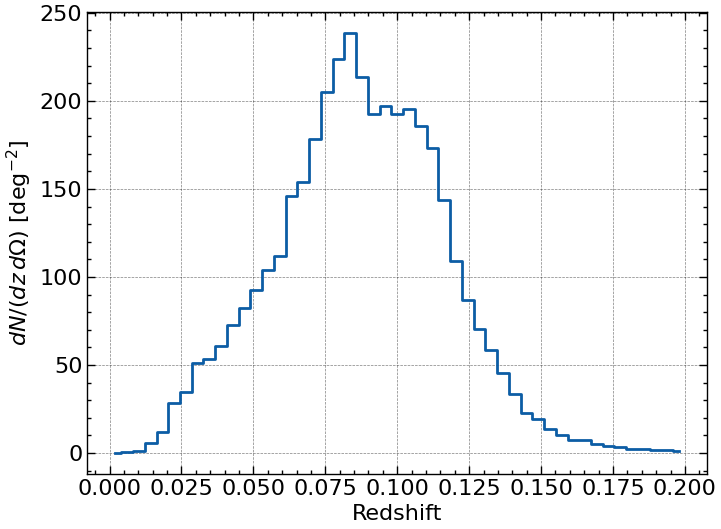

Text(0, 0.5, '$n(z)\\,[{\\rm Mpc}^{-3}]$')

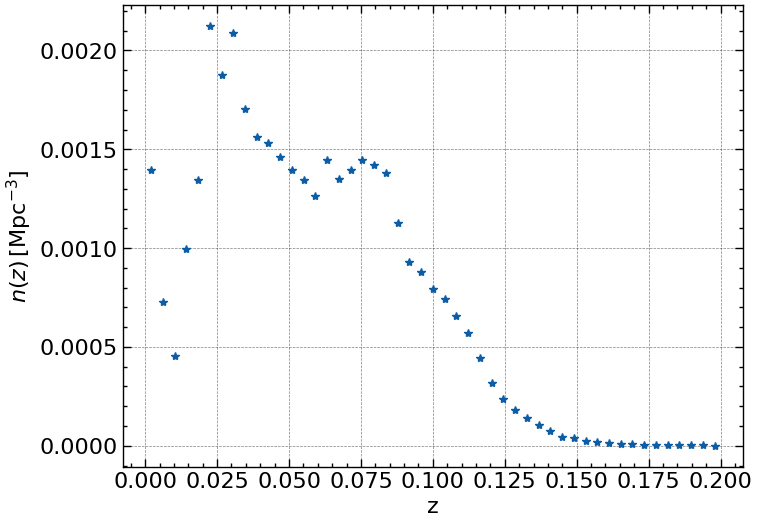

In [72]:
bins = np.linspace(0, 0.2, 100)

plt.plot(zcen, dN_dz_dOmega, drawstyle='steps-mid')
plt.xlabel('Redshift')
plt.ylabel(r'$dN/(dz\, d\Omega)$ [deg$^{-2}$]')
plt.show()

import pyccl as ccl

cosmo_hmcode = ccl.Cosmology(
    Omega_c=0.264,  # Cold dark matter density
    Omega_b=0.049,  # Baryon density
    h=0.674,        # Hubble parameter
    sigma8=0.811,    # Power spectrum normalization
    n_s=0.965       # Spectral index,
    ,matter_power_spectrum="camb",
    
    extra_parameters={
        "camb": {
            "halofit_version": "mead2020",

        }
    }

)
zcen = 0.5*(edges[1:]+edges[:-1])

chi = ccl.comoving_radial_distance(cosmo_hmcode, 1/(1+edges))  # in Mpc
volume = (
    omega/3.0 *
    (chi[1:]**3 - chi[:-1]**3)
)

n = N / volume
plt.plot(zcen,n,'*')
plt.xlabel('z')
plt.ylabel(r'$n(z)\,[{\rm Mpc}^{-3}]$')

In [ ]:
0.07

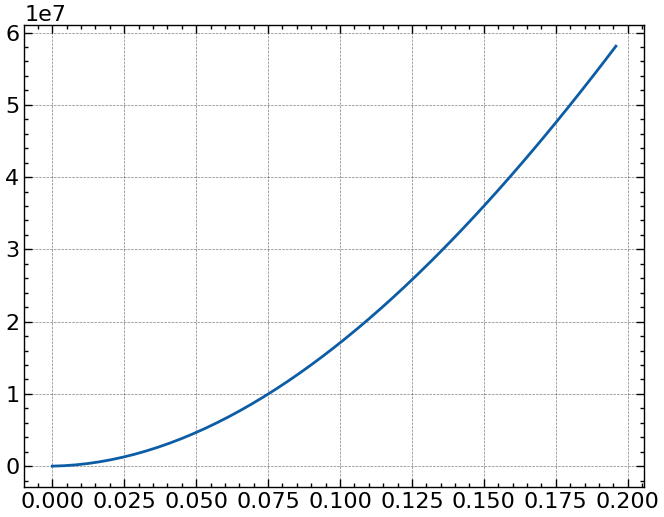

In [68]:
plt.plot(zbins[:-1],volume)

/tmp/ipykernel_671649/3444186807.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'Density')

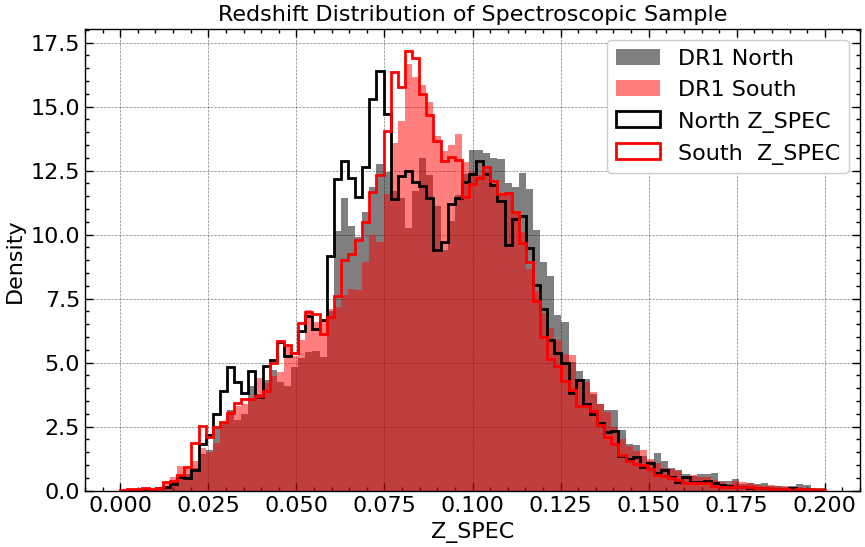

In [33]:

plt.figure(figsize=(10,6))
bins = np.linspace(0, 0.2, 100)
# plt.hist(spec_not_train(north_FP)['Z_SPEC'], bins=bins, alpha=0.5, label='North (Not in Training)', density=True,color = 'k')
# plt.hist(spec_not_train(south_FP)['Z_SPEC'], bins=bins, alpha=0.5, label='South (Not in Training)', density=True,color = 'r')
plt.legend()
plt.xlabel('Z_SPEC')
plt.ylabel('Density')   
plt.hist(matched_dr_north['Z'], bins=bins, alpha=0.5, label='DR1 North',density=True,color='k',lw=2)
plt.hist(matched_dr_south['Z'], bins=bins, alpha=0.5, label='DR1 South',density=True,color='r',lw=2)

plt.hist(north_FP['Z_SPEC'][north_FP['Z_SPEC']>0], bins=bins, label='North Z_SPEC', density=True, histtype='step', color='k',lw =2)
plt.hist(south_FP['Z_SPEC'][south_FP['Z_SPEC']>0], bins=bins,label='South  Z_SPEC', density=True, histtype='step', color='r',lw=2 )
plt.title('Redshift Distribution of Spectroscopic Sample')
plt.legend()
plt.xlabel('Z_SPEC')
plt.ylabel('Density')   

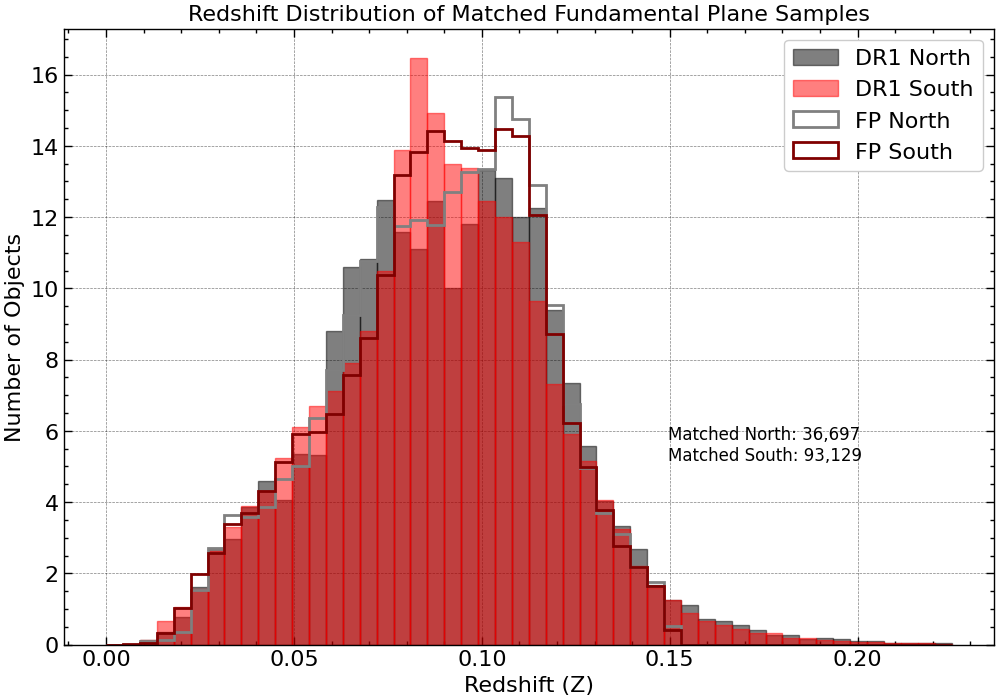

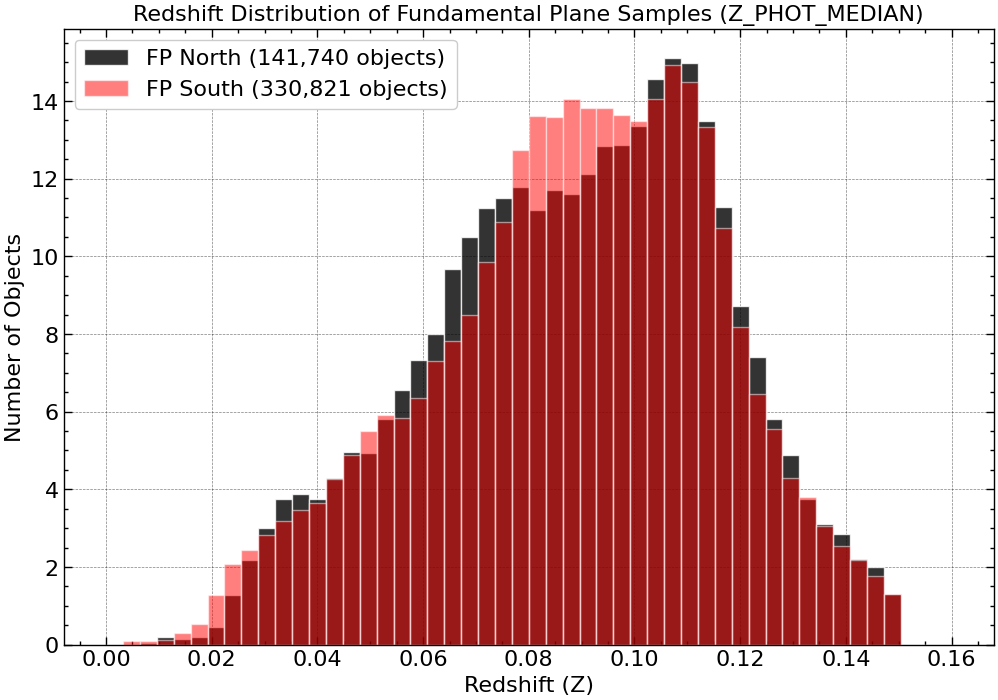

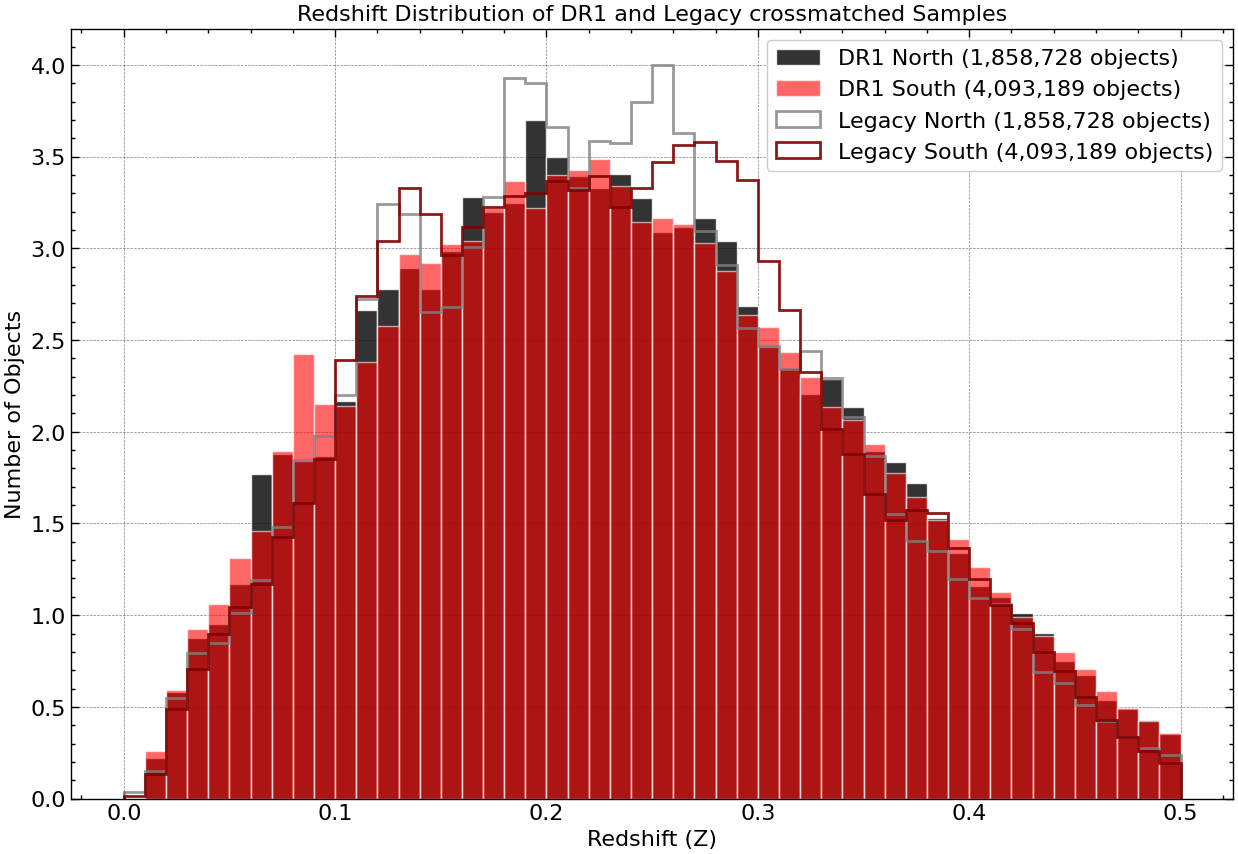

In [26]:
plt.figure(figsize=(12,8))
plt.hist(matched_dr_north['Z'], bins=50, alpha=0.5,range = (0,0.225), label='DR1 North',density=True,color='k',edgecolor='k')
plt.hist(matched_dr_south['Z'], bins=50, alpha=0.5,range = (0,0.225), label='DR1 South',density=True,color='r',edgecolor='r')
plt.hist(matched_north_FP['Z_PHOT_MEDIAN'], bins=50,range = (0,0.225), label='FP North',density=True,histtype='step',lw = 2,color='gray')
plt.hist(matched_south_FP['Z_PHOT_MEDIAN'], bins=50,range = (0,0.225), label='FP South',density=True,histtype='step',lw = 2,color='maroon')

plt.text(0.65, 0.3, f'Matched North: {len(matched_dr_north):,} \nMatched South: {len(matched_dr_south):,}', transform=plt.gca().transAxes, fontsize=12, color='k')
plt.xlabel('Redshift (Z)')
plt.ylabel('Number of Objects')
plt.title('Redshift Distribution of Matched Fundamental Plane Samples')
plt.legend()
plt.show()

plt.figure(figsize=(12,8))
plt.hist(north_FP['Z_PHOT_MEDIAN'], bins=50, alpha=0.8,range = (0,0.16), label=f'FP North ({len(north_FP):,} objects)',density=True,color='black',edgecolor='w')
plt.hist(south_FP['Z_PHOT_MEDIAN'], bins=50, alpha=0.5,range = (0,0.16), label=f'FP South ({len(south_FP):,} objects)',density=True,color='red',edgecolor='w')
plt.xlabel('Redshift (Z)')
plt.ylabel('Number of Objects')
plt.title('Redshift Distribution of Fundamental Plane Samples (Z_PHOT_MEDIAN)')
plt.legend()
plt.show()


plt.figure(figsize=(15,10))
plt.hist(dr_north['Z'], bins=50, alpha=0.8,range = (0,0.5), label=f'DR1 North ({len(dr_north):,} objects)',density=True,color='black',edgecolor='w')
plt.hist(dr_south['Z'], bins=50, alpha=0.6,range = (0,0.5), label=f'DR1 South ({len(dr_south):,} objects)',density=True,color='red',edgecolor='w')
plt.hist(legacy_north['Z_PHOT_MEDIAN'], bins=50, alpha=0.8,range = (0,0.5), label=f'Legacy North ({len(legacy_north):,} objects)',density=True,color='gray',histtype='step',lw = 2)
plt.hist(legacy_south['Z_PHOT_MEDIAN'], bins=50, alpha=0.9,range = (0,0.5), label=f'Legacy South ({len(legacy_south):,} objects)',density=True,color='maroon',histtype='step',lw = 2)
plt.xlabel('Redshift (Z)')
plt.ylabel('Number of Objects')
plt.title('Redshift Distribution of DR1 and Legacy crossmatched Samples')
plt.legend()
plt.show()

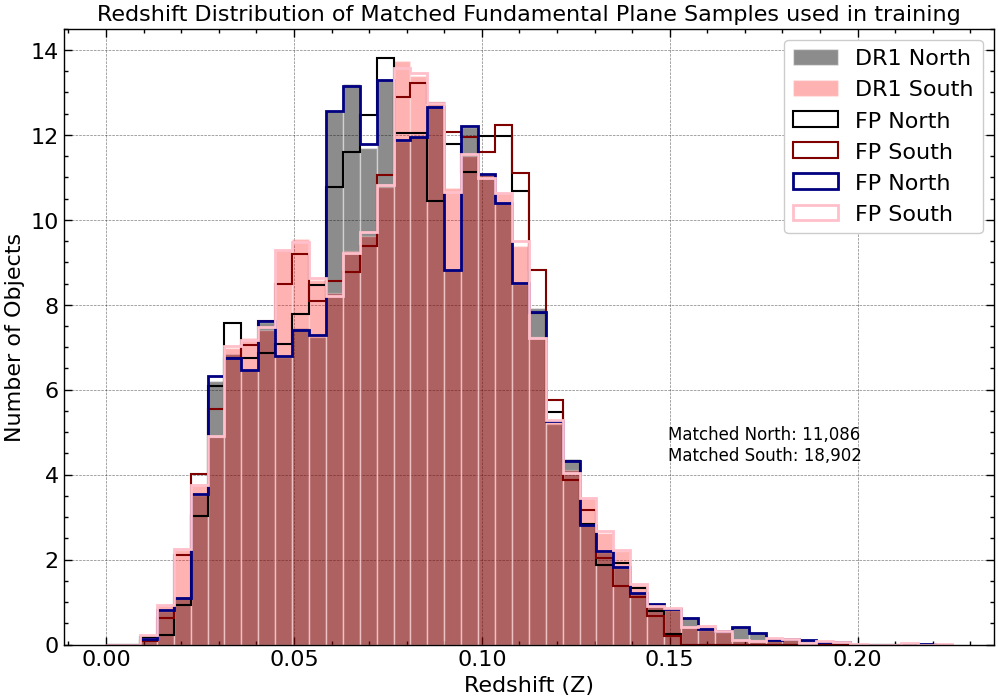

In [83]:
plt.figure(figsize=(12,8))
plt.hist(matched_dr_north['Z'][matched_north_FP['TRAINING']==True], bins=50, alpha=0.45,range = (0,0.225), label='DR1 North',density=True,color='k',edgecolor='w')
plt.hist(matched_dr_south['Z'][matched_south_FP['TRAINING']==True], bins=50, alpha=0.3,range = (0,0.225), label='DR1 South',density=True,color='r',edgecolor='w')
plt.hist(matched_north_FP['Z_PHOT_MEDIAN'][matched_north_FP['TRAINING']==True], bins=50,range = (0,0.225), label='FP North',density=True,histtype='step',lw = 1.5,color='k')
plt.hist(matched_south_FP['Z_PHOT_MEDIAN'][matched_south_FP['TRAINING']==True], bins=50,range = (0,0.225), label='FP South',density=True,histtype='step',lw = 1.5,color='maroon')
plt.hist(matched_north_FP['Z_SPEC'][matched_north_FP['TRAINING']==True], bins=50,range = (0,0.225), label='FP North',density=True,histtype='step',lw = 2,color='navy')
plt.hist(matched_south_FP['Z_SPEC'][matched_south_FP['TRAINING']==True], bins=50,range = (0,0.225), label='FP South',density=True,histtype='step',lw = 2,color='pink')
plt.text(0.65, 0.3, f'Matched North: {len(matched_dr_north["Z"][matched_north_FP["TRAINING"]==True]):,} \nMatched South: {len(matched_dr_south["Z"][matched_south_FP["TRAINING"]==True]):,}', transform=plt.gca().transAxes, fontsize=12, color='k')
plt.xlabel('Redshift (Z)')
plt.ylabel('Number of Objects')
plt.title('Redshift Distribution of Matched Fundamental Plane Samples used in training')
plt.legend()
plt.show()


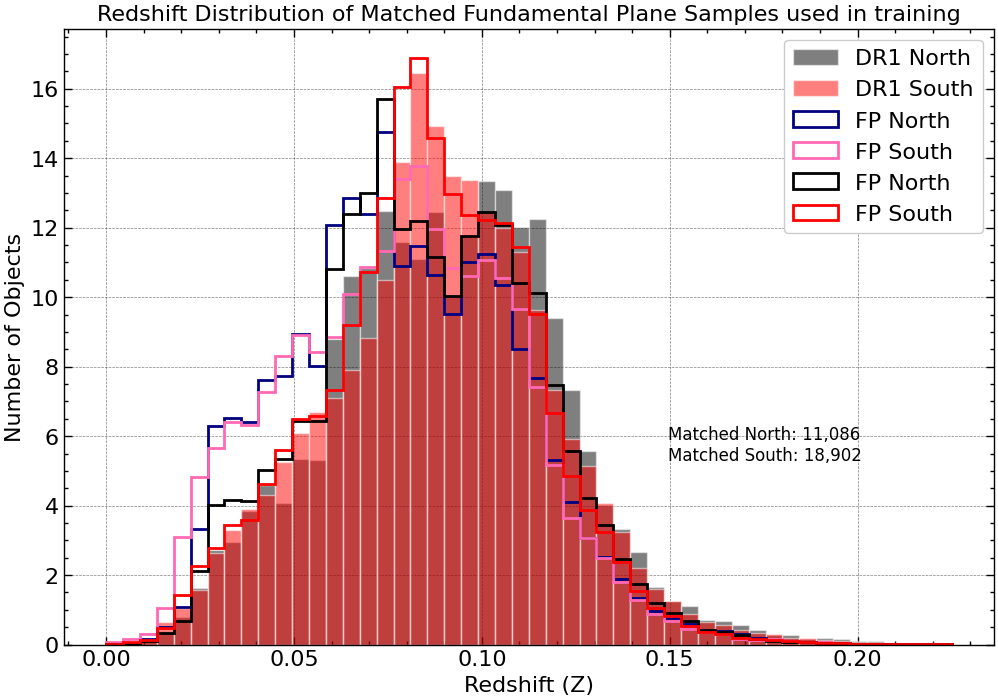

In [84]:
plt.figure(figsize=(12,8))
plt.hist(matched_dr_north['Z'], bins=50, alpha=0.5,range = (0,0.225), label='DR1 North',density=True,color='k',edgecolor='w')
plt.hist(matched_dr_south['Z'], bins=50, alpha=0.5,range = (0,0.225), label='DR1 South',density=True,color='r',edgecolor='w')
# plt.hist(matched_north_FP['Z_PHOT_MEDIAN'], bins=50,range = (0,0.225), label='FP North',density=True,histtype='step',lw = 1.5,color='k')
# plt.hist(matched_south_FP['Z_PHOT_MEDIAN'], bins=50,range = (0,0.225), label='FP South',density=True,histtype='step',lw = 1.5,color='maroon')
plt.hist(north_FP['Z_SPEC'][north_FP['TRAINING']==True], bins=50,range = (0,0.225), label='FP North',density=True,histtype='step',lw = 2,color='navy')
plt.hist(south_FP['Z_SPEC'][south_FP['TRAINING']==True], bins=50,range = (0,0.225), label='FP South',density=True,histtype='step',lw = 2,color='hotpink')
plt.hist(north_FP['Z_SPEC'][north_FP['Z_SPEC']>0], bins=50,range = (0,0.225), label='FP North',density=True,histtype='step',lw = 2,color='k')
plt.hist(south_FP['Z_SPEC'][south_FP['Z_SPEC']>0], bins=50,range = (0,0.225), label='FP South',density=True,histtype='step',lw = 2,color='r')

plt.text(0.65, 0.3, f'Matched North: {len(matched_dr_north["Z"][matched_north_FP["TRAINING"]==True]):,} \nMatched South: {len(matched_dr_south["Z"][matched_south_FP["TRAINING"]==True]):,}', transform=plt.gca().transAxes, fontsize=12, color='k')
plt.xlabel('Redshift (Z)')
plt.ylabel('Number of Objects')
plt.title('Redshift Distribution of Matched Fundamental Plane Samples used in training')
plt.legend()
plt.show()

In [69]:
legacy_north

array([(328953, '0063m002',  17, 'SER',   6.25041675, -0.17021   , [13778.196 , 20927.94  , 21254.77  , 21261.818 , 21376.52  ], 0.02456878, 0., 0., 45.857815, 50.351086, 38.84001 ,  140.91129 , -2.0745108e+02, 0., 0., 10.1556225, 1.8613803, 0.4560686 , 0.00061102, 0.9298532 , 0.9521896 , 0.97296876, 0.99584496, 0.99744624, 0.9994548 , 0.9997941 , 0, 0, 4, 0., 0., 0.00173492, 0., 0., 0.11308794, 0., 0., 0.92675614, 0., 0., 1.1987271, 0., 0., 92.782005, 1.6986859 ,  0.18743296, -0.1046515 , 0., 0.,  9.738936 , 0.,   0, 1.5460752, -99., -99., -99., -99., ' '),
       (328953, '0063m002', 103, 'REX',   6.25809588, -0.23824067, [29041.447 , 39707.41  , 39543.957 , 39774.375 ,     0.    ], 0.0235284 , 0., 0., 54.11024 , 73.26348 , 55.77212 ,  194.67848 ,  2.7940386e+03, 0., 0., 13.585382 , 1.8449593, 0.48617396, 0.0007321 , 0.93272126, 0.954167  , 0.97409844, 0.99602056, 0.99755424, 0.99947786, 0.9998028 , 0, 0, 2, 0., 0., 0.0166495 , 0., 0., 0.00429433, 0., 0., 0.99904066, 0., 0., 1.124423

In [86]:
legacy_north

array([(328953, '0063m002',  17, 'SER',   6.25041675, -0.17021   , [13778.196 , 20927.94  , 21254.77  , 21261.818 , 21376.52  ], 0.02456878, 0., 0., 45.857815, 50.351086, 38.84001 ,  140.91129 , -2.0745108e+02, 0., 0., 10.1556225, 1.8613803, 0.4560686 , 0.00061102, 0.9298532 , 0.9521896 , 0.97296876, 0.99584496, 0.99744624, 0.9994548 , 0.9997941 , 0, 0, 4, 0., 0., 0.00173492, 0., 0., 0.11308794, 0., 0., 0.92675614, 0., 0., 1.1987271, 0., 0., 92.782005, 1.6986859 ,  0.18743296, -0.1046515 , 0., 0.,  9.738936 , 0.,   0, 1.5460752, -99., -99., -99., -99., ' ', False),
       (328953, '0063m002', 103, 'REX',   6.25809588, -0.23824067, [29041.447 , 39707.41  , 39543.957 , 39774.375 ,     0.    ], 0.0235284 , 0., 0., 54.11024 , 73.26348 , 55.77212 ,  194.67848 ,  2.7940386e+03, 0., 0., 13.585382 , 1.8449593, 0.48617396, 0.0007321 , 0.93272126, 0.954167  , 0.97409844, 0.99602056, 0.99755424, 0.99947786, 0.9998028 , 0, 0, 2, 0., 0., 0.0166495 , 0., 0., 0.00429433, 0., 0., 0.99904066, 0., 0., 1

In [88]:
legacy_north['TRAINING']

array([False, False, False, ..., False, False, False])

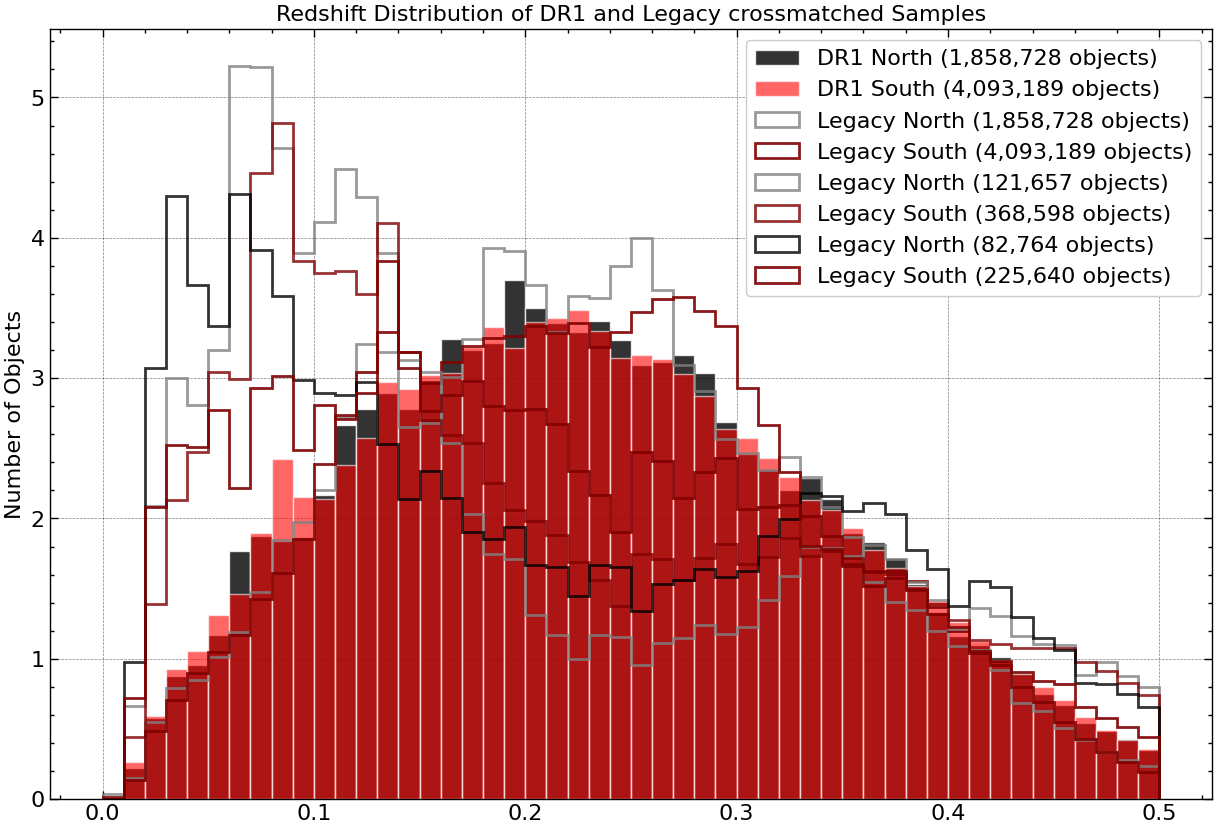

In [97]:

plt.figure(figsize=(15,10))
plt.hist(dr_north['Z'], bins=50, alpha=0.8,range = (0,0.5), label=f'DR1 North ({len(dr_north):,} objects)',density=True,color='black',edgecolor='w')
plt.hist(dr_south['Z'], bins=50, alpha=0.6,range = (0,0.5), label=f'DR1 South ({len(dr_south):,} objects)',density=True,color='red',edgecolor='w')
plt.hist(legacy_north['Z_PHOT_MEDIAN'], bins=50, alpha=0.8,range = (0,0.5), label=f'Legacy North ({len(legacy_north):,} objects)',density=True,color='gray',histtype='step',lw = 2)
plt.hist(legacy_south['Z_PHOT_MEDIAN'], bins=50, alpha=0.9,range = (0,0.5), label=f'Legacy South ({len(legacy_south):,} objects)',density=True,color='maroon',histtype='step',lw = 2)
plt.hist(legacy_north['Z_SPEC'][legacy_north['Z_SPEC']>0], bins=50, alpha=0.8,range = (0,0.5), label=f'Legacy North ({sum(legacy_north["Z_SPEC"]>0):,} objects)',density=True,color='gray',histtype='step',lw = 2)
plt.hist(legacy_south['Z_SPEC'][legacy_south['Z_SPEC']>0], bins=50, alpha=0.8,range = (0,0.5), label=f'Legacy South ({sum(legacy_south["Z_SPEC"]>0):,} objects)',density=True,color='maroon',histtype='step',lw = 2)

plt.hist(legacy_north['Z_SPEC'][legacy_north['TRAINING']==True], bins=50, alpha=0.8,range = (0,0.5), label=f'Legacy North ({sum(legacy_north["TRAINING"]==True):,} objects)',density=True,color='k',histtype='step',lw = 2)
plt.hist(legacy_south['Z_SPEC'][legacy_south['TRAINING']==True], bins=50, alpha=0.9,range = (0,0.5), label=f'Legacy South ({sum(legacy_south["TRAINING"]==True):,} objects)',density=True,color='maroon',histtype='step',lw = 2)

plt.ylabel('Number of Objects')
plt.title('Redshift Distribution of DR1 and Legacy crossmatched Samples')
plt.legend()
plt.show()